# RDKit Module 05: Substructure Searching

## Identifying Molecular Patterns Using SMARTS

## Learning Objectives

By the end of this notebook, you will be able to:

- Understand what substructure searching is
- Understand SMARTS notation
- Find whether a molecule contains a specific functional group
- Retrieve matching atom indices
- Highlight matched substructures
- Search multiple molecules
- Perform real-world functional group screening

## Why is Substructure Searching Important?

One of the most common tasks in cheminformatics is identifying whether a molecule contains a particular chemical fragment.

Examples include:

- Detecting functional groups
- Finding aromatic rings
- Screening compound libraries
- Identifying toxicophores
- Searching medicinal chemistry databases
- Compound filtering

Substructure searching is therefore one of the most frequently used operations in drug discovery and cheminformatics.

## What is a Substructure?

A substructure is a smaller molecular pattern present within a larger molecule.

For example:

Ethanol

CH3-CH2-OH

contains

Hydroxyl Group (-OH)

Similarly,

Aspirin contains

- Aromatic ring
- Ester
- Carboxylic acid

Each of these is a substructure.

## Why Do We Need Substructure Searching?

Modern pharmaceutical databases contain millions of chemical structures.

For example:

• ChEMBL
• PubChem
• DrugBank
• Internal pharmaceutical databases

Medicinal chemists rarely search for complete molecules.

Instead, they search for specific structural features such as:

- Alcohol group (-OH)
- Carboxylic acid (-COOH)
- Amide bond (-CONH-)
- Benzene ring
- Pyridine ring

Finding these structural features quickly is called substructure searching.

It is one of the most fundamental operations in cheminformatics.

## What is a Molecular Pattern?

A molecular pattern is a specific arrangement of atoms and bonds that can appear in many different molecules.

Examples include:

• Hydroxyl group (-OH)

• Carboxylic acid (-COOH)

• Amide bond (-CONH-)

• Benzene ring

• Pyridine ring

The same pattern may occur in hundreds, thousands, or even millions of molecules.

# Part:02 SMARTS

## What is SMARTS?

SMARTS is a molecular pattern language used to describe and search for specific chemical features within molecules.

Unlike SMILES, which represents one complete molecule, SMARTS represents a pattern that can match many different molecules.

SMARTS enables computers to identify common structural features such as:

- Functional groups
- Ring systems
- Heteroatoms
- Aromatic systems
- Specific bonding patterns

Because of its flexibility, SMARTS has become the standard language for substructure searching in cheminformatics.

## What Does SMARTS Stand For?

SMARTS stands for:

SMiles ARbitrary Target Specification

It was developed as an extension of the SMILES language.

While SMILES is designed to represent exact molecular structures,

SMARTS is designed to describe generalized molecular patterns that can be searched across large chemical databases.

##  =Why Do We Need SMARTS?

We already know that molecules can be represented using SMILES.

For example:

Ethanol      → CCO
Benzene      → c1ccccc1
Aspirin      → CC(=O)OC1=CC=CC=C1C(=O)O

SMILES is excellent for representing a specific molecule.

However, in cheminformatics we are often not interested in one specific molecule.

Instead, we want to search for common structural patterns that may exist in thousands or millions of different molecules.

This is where SMARTS becomes essential.

## Intuition: Why Isn't SMILES Enough?

Imagine you have a library containing 5 million books.

SMILES is like knowing the exact title of one book.

Example:

"The Great Gatsby"

You can find that exact book.

But suppose someone asks:

"Find every book that contains the word 'chemistry'."

The book title is no longer enough.

You need a search language.

SMARTS is exactly that search language for molecules.

In [1]:
# SMILES: Represent one exact molecule__Used for Molecule storage
# SMARTS:Represent a molecular pattern__Used for Substructure searching

# Part 03 SMARTS Grammar – Learning the Language of Molecular Patterns

## Why Learn SMARTS Grammar?

Before we can search molecular patterns, we must understand how SMARTS describes atoms and bonds.

Just as English uses letters to build words and sentences, SMARTS uses symbols to build molecular patterns.

Learning this grammar will allow you to read and write SMARTS expressions confidently.

# Essential SMARTS

## Creating SMARTS Objects

RDKit provides the function:

Chem.MolFromSmarts()

Unlike MolFromSmiles(), which creates a molecule,

MolFromSmarts() creates a molecular query.

This query is specifically designed for pattern matching rather than representing a complete molecule.

# Practial Example
Suppose you receive a small molecular library from a medicinal chemistry team.

Your task is to automatically identify compounds containing:

- Alcohol groups
- Carboxylic acid groups
- Amines (Basic compounds)

Instead of manually inspecting each molecule, we will use SMARTS patterns to classify them automatically.

In [3]:
from rdkit import Chem
import pandas as pd

In [4]:
compounds = {
    # Alcohols
    "Methanol": "CO",
    "Ethanol": "CCO",
    "1-Propanol": "CCCO",
    "2-Propanol": "CC(O)C",
    "Phenol": "Oc1ccccc1",

    # Carboxylic Acids
    "Formic Acid": "O=CO",
    "Acetic Acid": "CC(=O)O",
    "Propionic Acid": "CCC(=O)O",
    "Benzoic Acid": "O=C(O)c1ccccc1",
    "Salicylic Acid": "O=C(O)c1ccccc1O",

    # Amines (Bases)
    "Methylamine": "CN",
    "Ethylamine": "CCN",
    "Propylamine": "CCCN",
    "Aniline": "Nc1ccccc1",
    "Triethylamine": "CCN(CC)CC"
}

In [8]:
# Create SMARTS Patterns

alcohol_pattern=Chem.MolFromSmarts('CO')# CO:carbon Connected to Oxygen
acid_pattern=Chem.MolFromSmarts('C(=O)O')# C(=O)O: Carboxylic Acid functional group
amine_pattern=Chem.MolFromSmarts('N')# N: Nitrogen Atom

In [11]:
# Search Every Molecule

results=[]
for name, smiles in compounds.items():
    mol=Chem.MolFromSmiles(smiles)
    alcohol=mol.HasSubstructMatch(alcohol_pattern)
    acid=mol.HasSubstructMatch(acid_pattern)
    amine=mol.HasSubstructMatch(amine_pattern)

    results.append({'Compound':name,
                    'Alcohol':alcohol,
                    'Acid':acid,
                    'Amine':amine})
    df=pd.DataFrame(results)
    df


In [14]:
df

,Compound,Alcohol,Acid,Amine
0,Methanol,True,False,False
1,Ethanol,True,False,False
2,1-Propanol,True,False,False
3,2-Propanol,True,False,False
4,Phenol,False,False,False
5,Formic Acid,True,True,False
6,Acetic Acid,True,True,False
7,Propionic Acid,True,True,False
8,Benzoic Acid,True,True,False
9,Salicylic Acid,True,True,False


### Why are carboxylic acids classified as alcohols?

Our alcohol SMARTS is:

CO

This pattern only checks whether a carbon is connected to an oxygen.

A carboxylic acid also contains a carbon–oxygen bond.

Therefore, RDKit correctly reports a match.

This demonstrates that simple SMARTS patterns may match more molecules than intended.

Later, we will learn more specific SMARTS expressions to distinguish alcohols from carboxylic acids and phenols.

In [15]:
# Improved SMARTS Patterns

# Alcohol (Hydroxyl attached to saturated carbon)
alcohol_pattern = Chem.MolFromSmarts("[CX4][OX2H]")

# Carboxylic Acid
acid_pattern = Chem.MolFromSmarts("[CX3](=O)[OX2H1]")

# Primary, Secondary and Tertiary Amines
amine_pattern = Chem.MolFromSmarts("[NX3;H2,H1,H0]")


In [16]:
# Run the Classification again
results = []

for name, smiles in compounds.items():

    mol = Chem.MolFromSmiles(smiles)

    alcohol = mol.HasSubstructMatch(alcohol_pattern)
    acid = mol.HasSubstructMatch(acid_pattern)
    amine = mol.HasSubstructMatch(amine_pattern)

    results.append({
        "Compound": name,
        "Alcohol": alcohol,
        "Acid": acid,
        "Amine": amine
    })

df = pd.DataFrame(results)
df

,Compound,Alcohol,Acid,Amine
0,Methanol,True,False,False
1,Ethanol,True,False,False
2,1-Propanol,True,False,False
3,2-Propanol,True,False,False
4,Phenol,False,False,False
5,Formic Acid,False,True,False
6,Acetic Acid,False,True,False
7,Propionic Acid,False,True,False
8,Benzoic Acid,False,True,False
9,Salicylic Acid,False,True,False


## What is GetSubstructMatch()?

GetSubstructMatch() searches a molecule using a SMARTS pattern.

Instead of returning True or False,

it returns the atom indices corresponding to the first matching substructure.

Return type:

Tuple of atom indices

Example:

(1,2)

This means:

Atom 1 and Atom 2 together satisfy the SMARTS pattern

# Function
mol.GetSubstructMatch(pattern)

In [18]:
# Example
from rdkit import Chem

ethanol = Chem.MolFromSmiles("CCO")

pattern = Chem.MolFromSmarts("O")

ethanol.GetSubstructMatch(pattern)

(2,)

The oxygen atom in ethanol has atom index 2.
Therefore RDKit returns:
(2,)
Notice the comma.
Python represents a tuple containing one element as:
(2,)
rather than (2)

In [19]:
# Example
benzene = Chem.MolFromSmiles("c1ccccc1")

pattern = Chem.MolFromSmarts("c1ccccc1")

benzene.GetSubstructMatch(pattern)

(0, 1, 2, 3, 4, 5)

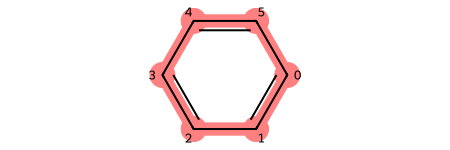

In [20]:
from rdkit.Chem.Draw import IPythonConsole

IPythonConsole.drawOptions.addAtomIndices=True

benzene

# function 2: GetSubstructMatches()

## Why Do We Need GetSubstructMatches()?

GetSubstructMatch() returns only the first matching substructure.

However, many molecules contain multiple occurrences of the same functional group.

Examples include:

- Multiple hydroxyl (-OH) groups
- Multiple amine groups
- Multiple aromatic rings
- Multiple carbonyl groups

To identify every occurrence, RDKit provides:

GetSubstructMatches()

In [22]:
# Example  Ethylen Glycol
from rdkit import Chem

mol = Chem.MolFromSmiles("OCCO")

pattern = Chem.MolFromSmarts("O")

mol.GetSubstructMatches(pattern)

((0,), (3,))

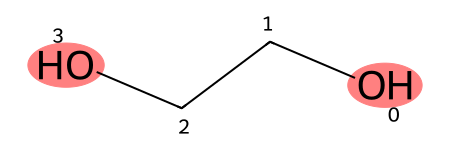

In [29]:
#Display Molecule
from rdkit.Chem import Draw
Draw.MolToImage(mol)

# show Atom Indices
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.drawOptions.addAtomIndices=True
mol


The molecule contains two oxygen atoms.

RDKit returns:

Atom 0

Atom 3

Each tuple represents one matching oxygen atom.

# Part 04: Highlighting Substructures

## Why Highlight Substructures?

Finding a substructure is only the first step.

Medicinal chemists often need to visually inspect where the matching functional group is located within the molecule.

Instead of interpreting atom indices manually,

RDKit can highlight the matched atoms directly on the molecular structure.

This makes it much easier to verify that the SMARTS pattern is identifying the intended chemical feature

## How Does Highlighting Work?

The workflow consists of three simple steps:

1. Create a SMARTS pattern.
2. Find the matching atom indices.
3. Pass those indices to RDKit's drawing function.

RDKit then colors the matching atoms, allowing us to visually confirm the search results

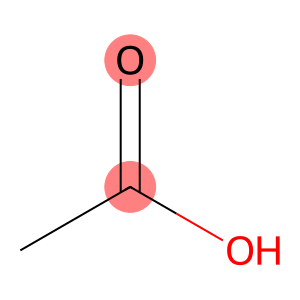

In [3]:
# Example

from rdkit import Chem
from rdkit.Chem import Draw
mol=Chem.MolFromSmiles('CC(=O)O')
pattern=Chem.MolFromSmarts('C=O')
match=mol.GetSubstructMatch(pattern)
Draw.MolToImage(mol,
                highlightAtoms=match)

✓ Substructure highlighting visually confirms SMARTS matches.

✓ GetSubstructMatch() is suitable for highlighting a single match.

✓ GetSubstructMatches() is used when multiple matches exist.

✓ Atom indices returned by RDKit can be directly passed to highlightAtoms after appropriate formatting.